# Data Exploration & Data Visualization
### DGA306 Data Analytics Techniques

---

ข้อมูลที่ใช้ใน Notebook นี้ เป็นข้อมูลบุคลากรหน่วยงานราชการจำลอง ไม่ใช่ข้อมูลจริง


---
## 1. Install and Import library <a id="s1"></a>

| Library | ใช้ทำอะไร |
|---------|-----------|
| `pandas` | จัดการข้อมูลตาราง (DataFrame) |
| `numpy` | คำนวณตัวเลข, สร้างข้อมูลสุ่ม |
| `matplotlib` | วาดกราฟพื้นฐาน ปรับแต่งได้ละเอียด |
| `seaborn` | วาดกราฟสถิติ สวยงาม ใช้ง่าย |


โดยปกติใน colab จะมีการติดตั้ง pandas ให้สามารถใช้งานได้อยู่แล้ว แต่สามารถทดลองการติดตั้งด้วยคำสั่งด้านล่างนี้ได้

In [106]:
!pip install pandas


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11


---
## 2. Loading Dataset <a id="s2"></a>

Notebook นี้ใช้ไฟล์ `employee_data.csv` ที่แนบมาด้วย  
เลือกใช้วิธีการสำหรับการอัปโหลดไฟล์เข้า Colab ด้านล่าง

---

**วิธีโหลดข้อมูลจากแหล่งต่าง ๆ (เลือกวิธีที่เหมาะสม)**
<div style="padding:12px;border-left:5px solid #4285F4;">
<b>วิธีที่ 1: อัปโหลดไฟล์จากเครื่อง</b><br>
<pre>
<code>
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('employee_data.csv')
</code>
</pre>
</div>

<div style="padding:12px;border-left:5px solid #4cfa4f;">
<b>วิธีที่ 2: โหลดจาก Google Drive</b><br>
<pre>
<code>
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/folder_name/employee_data.csv')
</code>
</pre>
</div>

<div style="padding:12px;border-left:5px solid #fa4c63;">
<b>วิธีที่ 3: ลาก & วางไฟล์ในแถบด้านซ้ายของ Colab</b><br>
<pre>
<code>
df = pd.read_csv('employee_data.csv')
</code>
</pre>
</div>

<div style="padding:12px;border-left:5px solid #f0e626;">
<b>วิธีที่ 4: โหลดจาก URL</b><br>
<pre>
<code>
url = 'https://example.com/your_file.csv'
df = pd.read_csv(url)
</code>
</pre>
</div>

<div style="padding:12px;border-left:5px solid #c04cfa;">
<b>วิธีที่ 5: โหลดจาก Unique ID จากไฟล์บน Google Drive Colab</b><br>
<pre>
<code>
file_id = "13zfmLHEAmXbbgrAq1aO8PNh8jsE7P7kK"
url = f"https://drive.google.com/uc?id={file_id}"
df = pd.read_csv(url)   # Load dataset
</code>
</pre>
</div>

---


In [ ]:
# เลือก 1 วิธีจากด้านบน แล้วใช้ cell นี้สำหรับการ Import ข้อมูล
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('employee_data.csv')

หลังจาก Import ข้อมูลเข้ามาแล้ว รัน cell ด้านล่าง

In [3]:
# โหลดข้อมูล
df = pd.read_csv('employee_data.csv')
df.head()


,employee_id,department,position,gender,age,years_of_service,education,salary,performance_score,sick_days,training_hours
0,DGA0001,Planning,Director,Female,59,28,Bachelor,15000.0,51.2,10,17
1,DGA0002,Finance,Director,Female,57,5,Bachelor,34700.0,96.2,0,31
2,DGA0003,HR,Officer,Female,57,4,Master,27600.0,63.1,18,95
3,DGA0004,Technology,Analyst,Male,36,3,Master,19900.0,84.9,3,98
4,DGA0005,Policy,Analyst,Male,27,19,Bachelor,49300.0,82.1,18,38


---
## 3. ตรวจสอบโครงสร้างข้อมูล <a id="s3"></a>

ก่อนวิเคราะห์ข้อมูลใด ๆ ต้องตอบคำถาม 3 ข้อนี้:
1. มีข้อมูลเท่าไหร่?
2. ข้อมูลแต่ละคอลัมน์เป็นชนิดอะไร?
3. มีค่าที่หายไปหรือไม่?


In [4]:
# ขนาดข้อมูล
df.shape


(120, 11)

In [5]:
# 5 แถวแรก
df.head()


,employee_id,department,position,gender,age,years_of_service,education,salary,performance_score,sick_days,training_hours
0,DGA0001,Planning,Director,Female,59,28,Bachelor,15000.0,51.2,10,17
1,DGA0002,Finance,Director,Female,57,5,Bachelor,34700.0,96.2,0,31
2,DGA0003,HR,Officer,Female,57,4,Master,27600.0,63.1,18,95
3,DGA0004,Technology,Analyst,Male,36,3,Master,19900.0,84.9,3,98
4,DGA0005,Policy,Analyst,Male,27,19,Bachelor,49300.0,82.1,18,38


In [6]:
# 5 แถวสุดท้าย
df.tail()


,employee_id,department,position,gender,age,years_of_service,education,salary,performance_score,sick_days,training_hours
115,DGA0116,Finance,Staff,Female,56,14,Bachelor,29900.0,78.9,2,72
116,DGA0117,HR,Analyst,Male,45,9,Bachelor,29300.0,96.1,9,67
117,DGA0118,Policy,Analyst,Female,40,14,Master,46400.0,67.6,1,13
118,DGA0119,Finance,Staff,Female,45,1,Master,NaN,47.2,12,100
119,DGA0120,Technology,Analyst,Female,35,19,Bachelor,26200.0,60.2,12,97


In [7]:
# ชนิดข้อมูลแต่ละคอลัมน์
df.dtypes


employee_id           object
department            object
position              object
gender                object
age                    int64
years_of_service       int64
education             object
salary               float64
performance_score    float64
sick_days              int64
training_hours         int64
dtype: object

In [8]:
# สรุปโครงสร้างข้อมูล: ชนิด + จำนวนค่าที่ไม่ใช่ null
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   employee_id        120 non-null    object 
 1   department         120 non-null    object 
 2   position           120 non-null    object 
 3   gender             120 non-null    object 
 4   age                120 non-null    int64  
 5   years_of_service   120 non-null    int64  
 6   education          120 non-null    object 
 7   salary             115 non-null    float64
 8   performance_score  115 non-null    float64
 9   sick_days          120 non-null    int64  
 10  training_hours     120 non-null    int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 10.4+ KB


In [9]:
# ตรวจค่าที่หายไป (Missing Values)
df.isnull().sum()


employee_id          0
department           0
position             0
gender               0
age                  0
years_of_service     0
education            0
salary               5
performance_score    5
sick_days            0
training_hours       0
dtype: int64

In [10]:
# ตรวจแถวซ้ำ (Duplicates)
df.duplicated().sum()


0

**Playground** ลองเปลี่ยนตัวเลขใน `head()` และ `tail()` เป็นค่าอื่น แล้วสังเกตผล


In [11]:
df.head(10)


,employee_id,department,position,gender,age,years_of_service,education,salary,performance_score,sick_days,training_hours
0,DGA0001,Planning,Director,Female,59,28,Bachelor,15000.0,51.2,10,17
1,DGA0002,Finance,Director,Female,57,5,Bachelor,34700.0,96.2,0,31
2,DGA0003,HR,Officer,Female,57,4,Master,27600.0,63.1,18,95
3,DGA0004,Technology,Analyst,Male,36,3,Master,19900.0,84.9,3,98
4,DGA0005,Policy,Analyst,Male,27,19,Bachelor,49300.0,82.1,18,38
5,DGA0006,Policy,Officer,Female,25,20,Bachelor,34500.0,94.8,10,45
6,DGA0007,Policy,Director,Male,57,25,Bachelor,37100.0,71.8,7,115
7,DGA0008,Finance,Director,Female,34,18,Bachelor,NaN,60.8,10,28
8,DGA0009,Technology,Analyst,Female,53,15,Bachelor,34900.0,51.7,3,61
9,DGA0010,HR,Officer,Female,37,9,Master,40400.0,33.2,16,112


---
## 4. สำรวจข้อมูล Categorical <a id="s4"></a>

**Categorical Data** คือข้อมูลที่เป็นหมวดหมู่หรือประเภท เช่น department, position, gender, education

| คำสั่ง | ความหมาย |
|--------|----------|
| `value_counts()` | นับจำนวนแต่ละประเภท |
| `unique()` | แสดงค่าที่ไม่ซ้ำกัน |
| `nunique()` | นับจำนวนประเภทที่ไม่ซ้ำ |
| `value_counts(normalize=True)` | แสดงเป็นสัดส่วน |
| `groupby()` | สรุปข้อมูลแยกตามกลุ่ม |


In [12]:
# นับจำนวนแต่ละประเภท
df['department'].value_counts()


department
Policy        35
Planning      23
Technology    23
HR            22
Finance       17
Name: count, dtype: int64

In [13]:
# ค่าที่ไม่ซ้ำกัน
print(df['department'].unique())
print(f"มีทั้งหมด {df['department'].nunique()} แผนก")


['Planning' 'Finance' 'HR' 'Technology' 'Policy']
มีทั้งหมด 5 แผนก


In [14]:
# สัดส่วน (%)
df['gender'].value_counts(normalize=True).mul(100).round(1)


gender
Female    59.2
Male      40.8
Name: proportion, dtype: float64

In [15]:
# เงินเดือนเฉลี่ยต่อแผนก
df.groupby('department')['salary'].mean().round(0).sort_values(ascending=False)


department
Policy        37234.0
Technology    36674.0
Finance       36367.0
Planning      36162.0
HR            35310.0
Name: salary, dtype: float64

In [16]:
# สรุปหลายตัวเลขพร้อมกัน
df.groupby('department').agg(
    count           = ('employee_id', 'count'),
    avg_salary      = ('salary', 'mean'),
    avg_performance = ('performance_score', 'mean')
).round(1)


,count,avg_salary,avg_performance
department,,,
Finance,17,36366.7,75.9
HR,22,35309.5,73.8
Planning,23,36161.9,76.8
Policy,35,37234.3,75.8
Technology,23,36673.9,73.3


**Playground** — ลองดูจำนวนบุคลากรแยกตาม `education` และสัดส่วนของแต่ละระดับ


In [17]:
# ลองทำ 4.1
# df['???'].value_counts()
# df['???'].value_counts(normalize=True).mul(100).round(1)


---
## 5. สำรวจข้อมูล Numerical <a id="s5"></a>

**Numerical Data** คือข้อมูลที่เป็นตัวเลขที่นำไปคำนวณได้ เช่น age, salary, performance_score

- **Mean** — ค่าเฉลี่ย
- **Median** — ค่ากลาง ไม่ถูกกระทบโดย outlier
- **Std** — ส่วนเบี่ยงเบนมาตรฐาน ยิ่งมาก ยิ่งกระจาย
- **Min / Max** — ค่าต่ำสุดและสูงสุด


In [18]:
# สถิติพื้นฐานของตัวแปรตัวเลข
df.describe().round(1)


,age,years_of_service,salary,performance_score,sick_days,training_hours
count,120.0,120.0,115.0,115.0,120.0,120.0
mean,42.6,15.3,36461.7,75.1,9.7,61.8
std,10.0,8.6,12128.1,16.0,5.6,35.5
min,25.0,1.0,15000.0,33.2,0.0,2.0
25%,34.0,8.0,28200.0,64.2,5.8,33.2
50%,43.0,16.0,36000.0,75.6,10.0,61.0
75%,51.0,22.0,43700.0,89.3,15.0,95.5
max,59.0,29.0,70700.0,100.0,19.0,119.0


In [19]:
# สถิติแยกทีละคอลัมน์
df['salary'].agg(['mean', 'median', 'std', 'min', 'max']).round(0)


mean      36462.0
median    36000.0
std       12128.0
min       15000.0
max       70700.0
Name: salary, dtype: float64

In [20]:
# เงินเดือนตามวุฒิการศึกษา
df.groupby('education')['salary'].agg(['mean', 'median', 'std']).round(0)


,mean,median,std
education,,,
Bachelor,37093.0,37550.0,12980.0
Master,35424.0,34550.0,11649.0
PhD,39600.0,38400.0,9118.0


In [21]:
# Correlation Matrix
num_cols = ['age', 'years_of_service', 'salary', 'performance_score', 'sick_days', 'training_hours']
df[num_cols].corr().round(2)


,age,years_of_service,salary,performance_score,sick_days,training_hours
age,1.00,-0.03,-0.10,0.09,-0.09,0.11
years_of_service,-0.03,1.00,-0.08,0.07,0.06,-0.24
salary,-0.10,-0.08,1.00,0.05,0.03,0.01
performance_score,0.09,0.07,0.05,1.00,-0.04,0.09
sick_days,-0.09,0.06,0.03,-0.04,1.00,-0.10
training_hours,0.11,-0.24,0.01,0.09,-0.10,1.00


---
## 6. (Extra for day 1) จัดการค่าที่หายไปและค่าผิดปกติ <a id="s6"></a>

<span style="color:red">**จำเป็นต้องรัน part นี้ก่อนถึง Part 7 (part ถัดไป)**</span>


(เนื่องด้วยเนื้อหาส่วนนี้ยังไม่มีสอนใน Day 1 สามารถรันให้ผ่านไปก่อนโดยยังไม่ต้องสนใจเนื้อหาเพื่อให้ใช้งานในส่วน Visualization ได้)

**ตัวเลือกสำหรับค่าที่หายไป:**

| วิธี | เหมาะกับ |
|------|---------|
| `dropna()` | ข้อมูลหายไปน้อย / แถวนั้นไม่สำคัญ |
| `fillna(median)` | ตัวแปรตัวเลข มี outlier |
| `fillna(mean)` | ตัวแปรตัวเลข ไม่มี outlier |
| `fillna(mode)` | ตัวแปร categorical |


In [22]:
# ดูว่ามีค่าหายไปในคอลัมน์ไหนบ้าง
df.isnull().sum()[df.isnull().sum() > 0]


salary               5
performance_score    5
dtype: int64

In [23]:
# เติมด้วยค่า median
df_clean = df.copy()
df_clean['salary'].fillna(df_clean['salary'].median(), inplace=True)
df_clean['performance_score'].fillna(df_clean['performance_score'].median(), inplace=True)

print(f"Missing หลังเติมค่า: {df_clean.isnull().sum().sum()}")


Missing หลังเติมค่า: 0


In [24]:
# ตรวจหา Outlier ด้วย IQR Method
def detect_outliers(series, label):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((series < lower) | (series > upper)).sum()
    print(f"  {label:20s}: {n_out:3d} outliers  (normal range: {lower:,.0f} – {upper:,.0f})")

print("Outlier Check:")
for col in ['salary', 'performance_score', 'sick_days', 'training_hours']:
    detect_outliers(df_clean[col].dropna(), col)


Outlier Check:
  salary              :   1 outliers  (normal range: 6,738 – 65,438)
  performance_score   :   0 outliers  (normal range: 29 – 124)
  sick_days           :   0 outliers  (normal range: -8 – 29)
  training_hours      :   0 outliers  (normal range: -60 – 189)


---
## 7. Data Visualization — matplotlib <a id="s7"></a>

**matplotlib** คือ library วาดกราฟพื้นฐานของ Python ปรับแต่งได้ทุกรายละเอียด

```python
plt.figure(figsize=(width, height))
plt.plot_type(...)
plt.title("...")
plt.xlabel("...")
plt.ylabel("...")
plt.show()
```


### 7.1 Bar Chart

ใช้เมื่อต้องการเปรียบเทียบค่าระหว่างกลุ่ม เช่น จำนวนคนต่อแผนก หรือเงินเดือนเฉลี่ยต่อตำแหน่ง


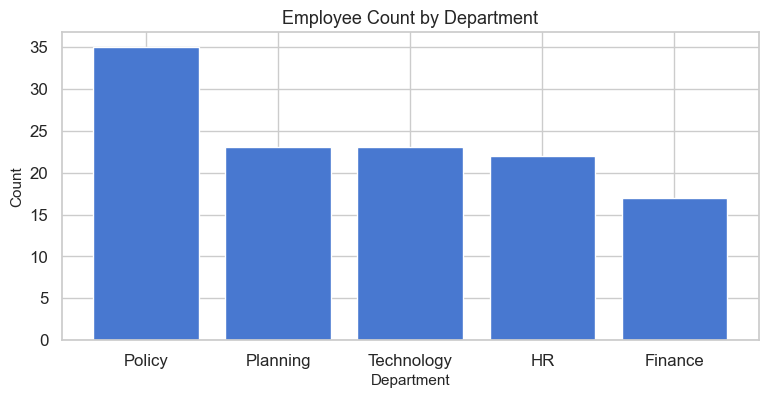

In [ ]:
# Simple
dept_counts = df_clean['department'].value_counts()
plt.bar(dept_counts.index, dept_counts.values)
plt.title("Employee Count by Department")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

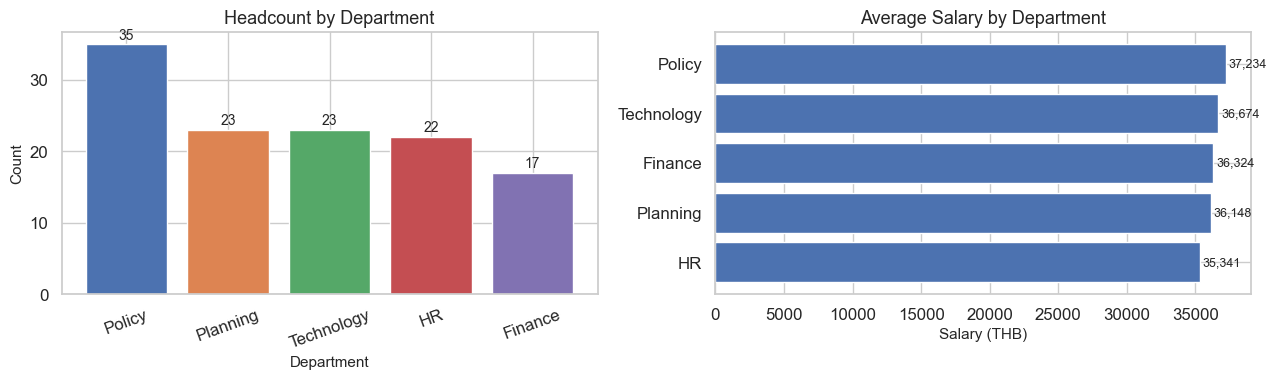

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Count per department
dept_counts = df_clean['department'].value_counts()
bars = axes[0].bar(dept_counts.index, dept_counts.values,
                   color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'],
                   edgecolor='white')
for bar, val in zip(bars, dept_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontsize=10)
axes[0].set_title("Headcount by Department")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=20)

# Average salary per department (horizontal)
avg_salary = df_clean.groupby('department')['salary'].mean().sort_values()
axes[1].barh(avg_salary.index, avg_salary.values, color='#4C72B0', edgecolor='white')
for i, val in enumerate(avg_salary.values):
    axes[1].text(val + 200, i, f'{val:,.0f}', va='center', fontsize=9)
axes[1].set_title("Average Salary by Department")
axes[1].set_xlabel("Salary (THB)")

plt.tight_layout()
plt.show()


### 7.2 Pie Chart

ใช้เมื่อต้องการเห็นสัดส่วนของแต่ละส่วนจากทั้งหมด  
เหมาะกับข้อมูลที่มีประเภทไม่เกิน 5–6 ประเภท  
seaborn ไม่รองรับ pie chart ต้องใช้ matplotlib เท่านั้น


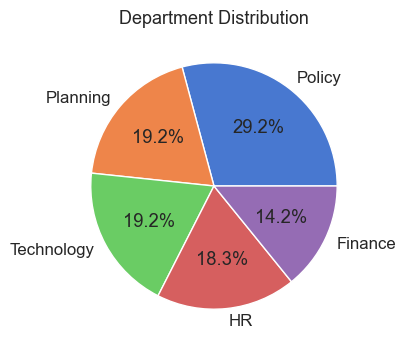

In [ ]:
# Simple
dept_counts = df_clean['department'].value_counts()
plt.pie(dept_counts.values, labels=dept_counts.index, autopct='%1.1f%%')
plt.title("Department Distribution")
plt.show()

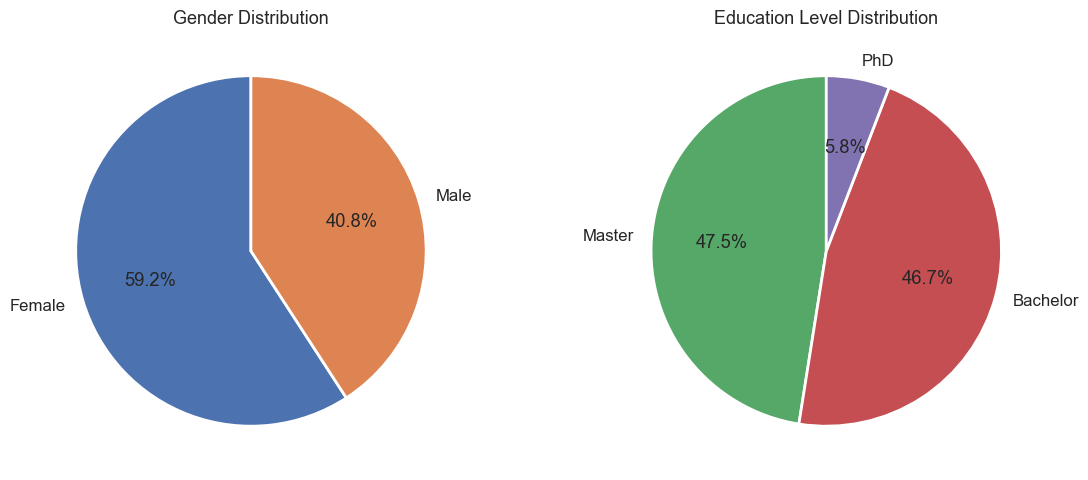

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gender_counts = df_clean['gender'].value_counts()
axes[0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            startangle=90, colors=['#4C72B0','#DD8452'],
            wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[0].set_title("Gender Distribution")

edu_counts = df_clean['education'].value_counts()
axes[1].pie(edu_counts.values, labels=edu_counts.index, autopct='%1.1f%%',
            startangle=90,
            colors=['#55A868','#C44E52','#8172B2'],
            wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[1].set_title("Education Level Distribution")

plt.tight_layout()
plt.show()


### 7.3 Histogram

ใช้เมื่อต้องการดูว่าข้อมูลกระจายตัวอย่างไร  
`bins` = จำนวนช่วง


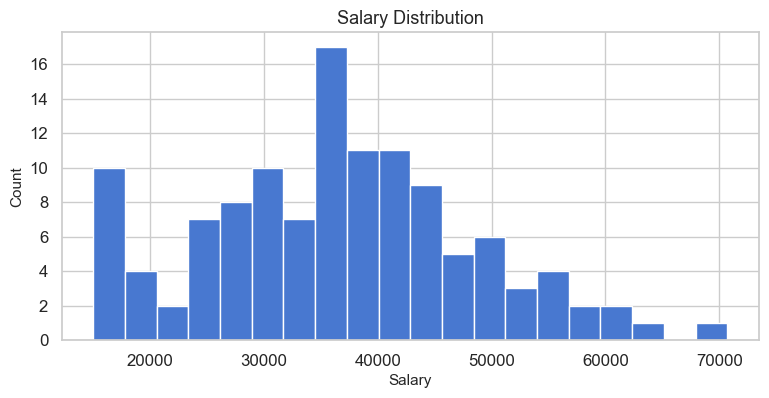

In [ ]:
# Simple
plt.hist(df_clean['salary'], bins=20)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

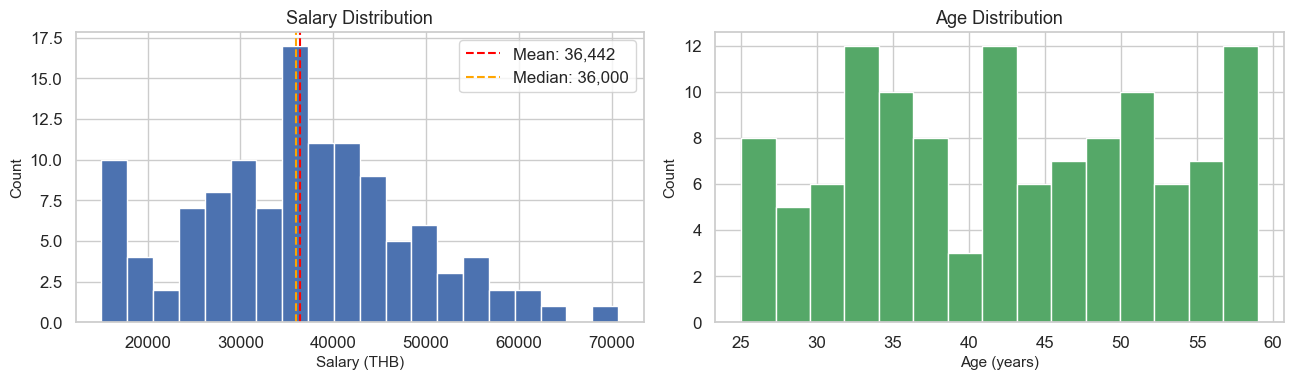

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_clean['salary'].dropna(), bins=20, color='#4C72B0', edgecolor='white')
axes[0].axvline(df_clean['salary'].mean(),   color='red',    linestyle='--', linewidth=1.5,
                label=f"Mean: {df_clean['salary'].mean():,.0f}")
axes[0].axvline(df_clean['salary'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f"Median: {df_clean['salary'].median():,.0f}")
axes[0].set_title("Salary Distribution")
axes[0].set_xlabel("Salary (THB)")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(df_clean['age'], bins=15, color='#55A868', edgecolor='white')
axes[1].set_title("Age Distribution")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


### 7.4 Multiple Histogram

เปรียบเทียบการกระจายระหว่างกลุ่ม โดยซ้อน histogram ของแต่ละกลุ่มไว้ด้วยกัน  
ใช้ `alpha` เพื่อทำให้โปร่งแสง เห็นทับกันได้


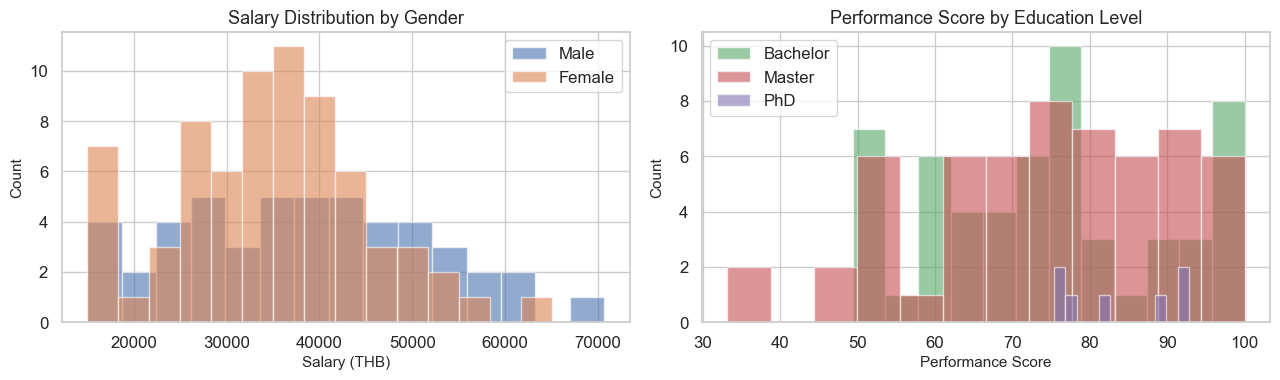

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for gender, color in zip(['Male','Female'], ['#4C72B0','#DD8452']):
    subset = df_clean[df_clean['gender'] == gender]['salary']
    axes[0].hist(subset, bins=15, alpha=0.6, label=gender, color=color, edgecolor='white')
axes[0].set_title("Salary Distribution by Gender")
axes[0].set_xlabel("Salary (THB)")
axes[0].set_ylabel("Count")
axes[0].legend()

for edu, color in zip(['Bachelor','Master','PhD'], ['#55A868','#C44E52','#8172B2']):
    subset = df_clean[df_clean['education'] == edu]['performance_score']
    axes[1].hist(subset, bins=12, alpha=0.6, label=edu, color=color, edgecolor='white')
axes[1].set_title("Performance Score by Education Level")
axes[1].set_xlabel("Performance Score")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()


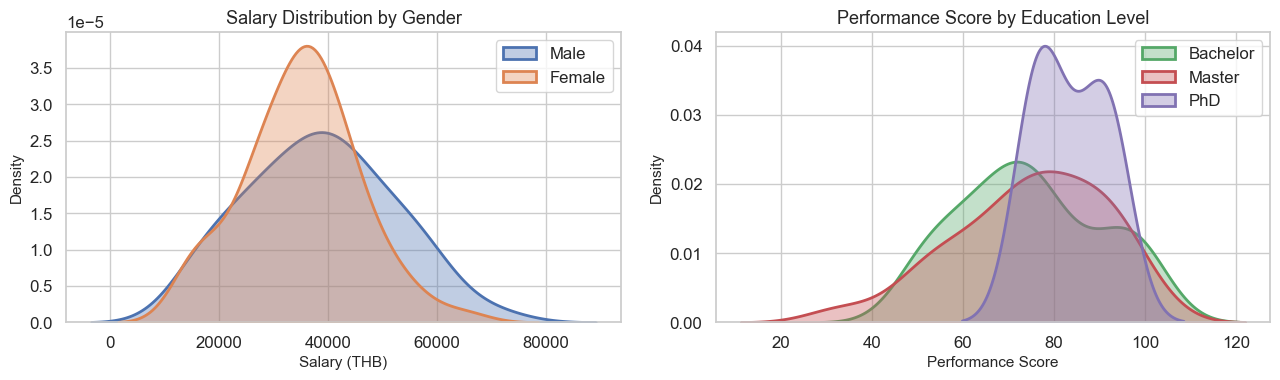

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for gender, color in zip(['Male', 'Female'], ['#4C72B0', '#DD8452']):
    subset = df_clean[df_clean['gender'] == gender]['salary']
    sns.kdeplot(
        subset,
        ax=axes[0],
        label=gender,
        color=color,
        fill=True,
        alpha=0.35,
        linewidth=2
    )

axes[0].set_title("Salary Distribution by Gender")
axes[0].set_xlabel("Salary (THB)")
axes[0].set_ylabel("Density")
axes[0].legend()

for edu, color in zip(['Bachelor', 'Master', 'PhD'], ['#55A868', '#C44E52', '#8172B2']):
    subset = df_clean[df_clean['education'] == edu]['performance_score']
    sns.kdeplot(
        subset,
        ax=axes[1],
        label=edu,
        color=color,
        fill=True,
        alpha=0.35,
        linewidth=2
    )

axes[1].set_title("Performance Score by Education Level")
axes[1].set_xlabel("Performance Score")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

### 7.5 Boxplot

แสดงการกระจายข้อมูลผ่าน quartile และตรวจ outlier

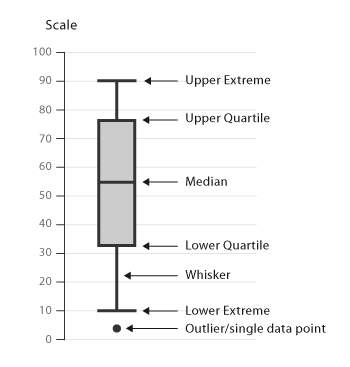

ขอขอบคุณภาพ boxplot จาก [link](https://datavizcatalogue.com/methods/box_plot.html)

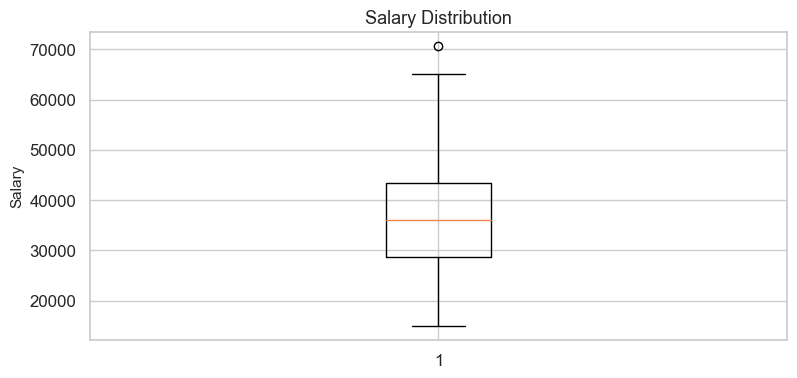

In [ ]:
# Simple
plt.boxplot(df_clean['salary'].dropna())
plt.title("Salary Distribution")
plt.ylabel("Salary")
plt.show()

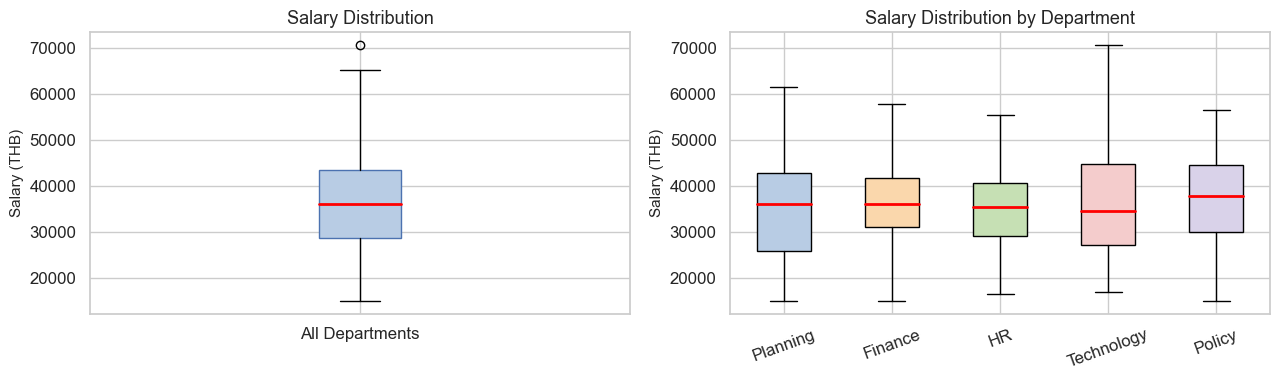

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].boxplot(df_clean['salary'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#B8CCE4', color='#4C72B0'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title("Salary Distribution")
axes[0].set_ylabel("Salary (THB)")
axes[0].set_xticklabels(['All Departments'])

depts = df_clean['department'].unique()
data_per_dept = [df_clean[df_clean['department'] == d]['salary'].dropna().values for d in depts]
bp = axes[1].boxplot(data_per_dept, labels=depts, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
colors = ['#B8CCE4','#FAD7AC','#C6E0B4','#F4CCCC','#D9D2E9']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_title("Salary Distribution by Department")
axes[1].set_ylabel("Salary (THB)")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


### 7.6 Scatterplot

แสดงความสัมพันธ์ระหว่าง 2 ตัวแปร เช่น อายุกับเงินเดือน มีความสัมพันธ์กันหรือไม่


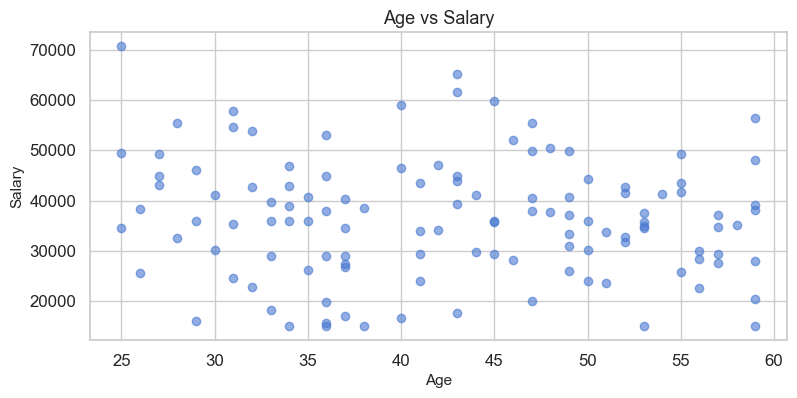

In [ ]:
# Simple
plt.scatter(df_clean['age'], df_clean['salary'], alpha=0.6)
plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

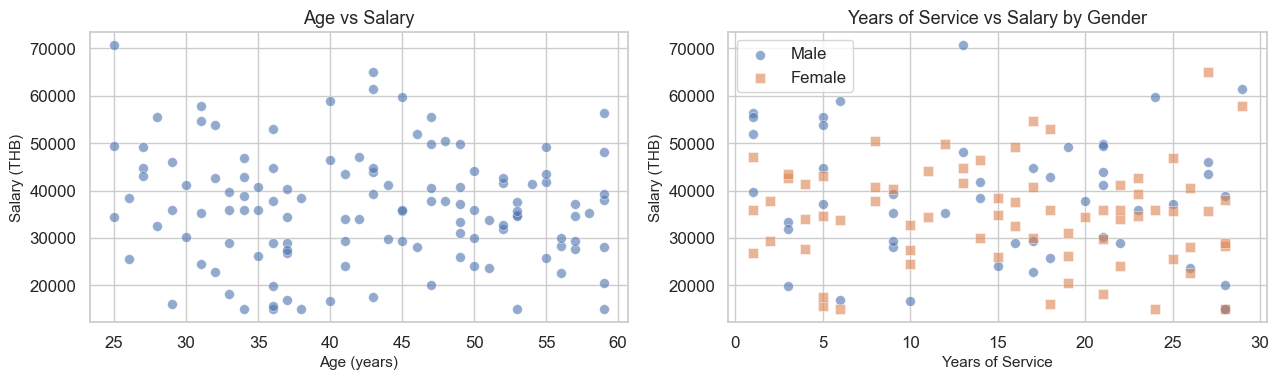

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(df_clean['age'], df_clean['salary'],
                alpha=0.6, s=50, c='#4C72B0', edgecolors='white', linewidths=0.5)
axes[0].set_title("Age vs Salary")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Salary (THB)")

for gender, color, marker in zip(['Male','Female'], ['#4C72B0','#DD8452'], ['o','s']):
    subset = df_clean[df_clean['gender'] == gender]
    axes[1].scatter(subset['years_of_service'], subset['salary'],
                    alpha=0.6, s=50, color=color, marker=marker,
                    label=gender, edgecolors='white', linewidths=0.5)
axes[1].set_title("Years of Service vs Salary by Gender")
axes[1].set_xlabel("Years of Service")
axes[1].set_ylabel("Salary (THB)")
axes[1].legend()

plt.tight_layout()
plt.show()


---
## 8. Data Visualization — seaborn <a id="s8"></a>

**seaborn** สร้างบน matplotlib แต่เขียนโค้ดน้อยกว่า และให้กราฟที่มีความสวยงาม  
จุดเด่นคือ `hue=` ที่แบ่งสีตาม category ได้ทันที

| | matplotlib | seaborn |
|--|------------|---------|
| โค้ด | ยาวกว่า | สั้นกว่า |
| ความยืดหยุ่น | สูงมาก | ปานกลาง |
| `hue` (แยกกลุ่ม) | ต้อง loop เอง | `hue=` พารามิเตอร์เดียว |
| เหมาะกับ | งาน publication | EDA เบื้องต้น |


### 8.1 Bar Chart


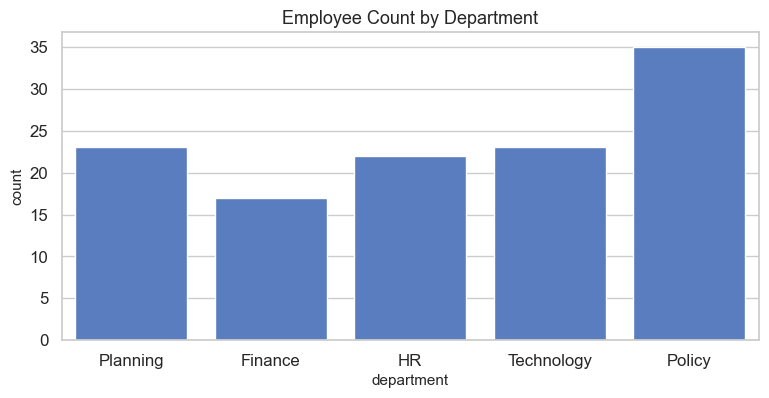

In [ ]:
# Simple
sns.countplot(data=df_clean, x='department')
plt.title("Employee Count by Department")
plt.show()

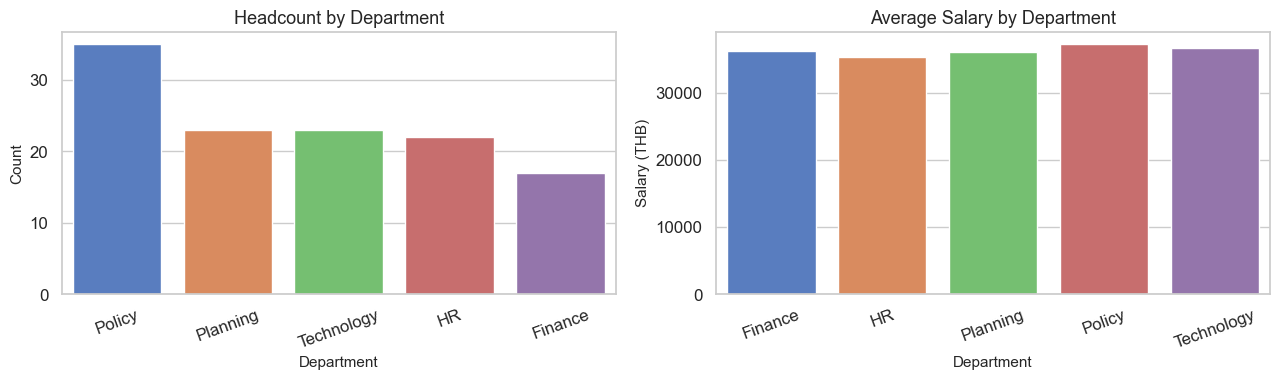

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(data=df_clean, x='department', ax=axes[0], palette='muted',
              order=df_clean['department'].value_counts().index)
axes[0].set_title("Headcount by Department")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=20)

avg_salary = df_clean.groupby('department')['salary'].mean().reset_index()
avg_salary.columns = ['department', 'avg_salary']
sns.barplot(data=avg_salary, x='department', y='avg_salary', ax=axes[1], palette='muted')
axes[1].set_title("Average Salary by Department")
axes[1].set_xlabel("Department")
axes[1].set_ylabel("Salary (THB)")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


### 8.2 Histogram + KDE

`kde=True` เพิ่มเส้นโค้ง Kernel Density Estimate แสดงรูปร่างการกระจายข้อมูล


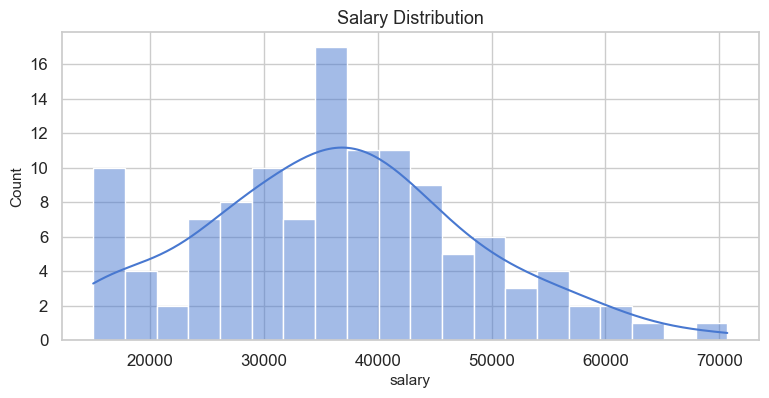

In [ ]:
# Simple
sns.histplot(data=df_clean, x='salary', bins=20, kde=True)
plt.title("Salary Distribution")
plt.show()

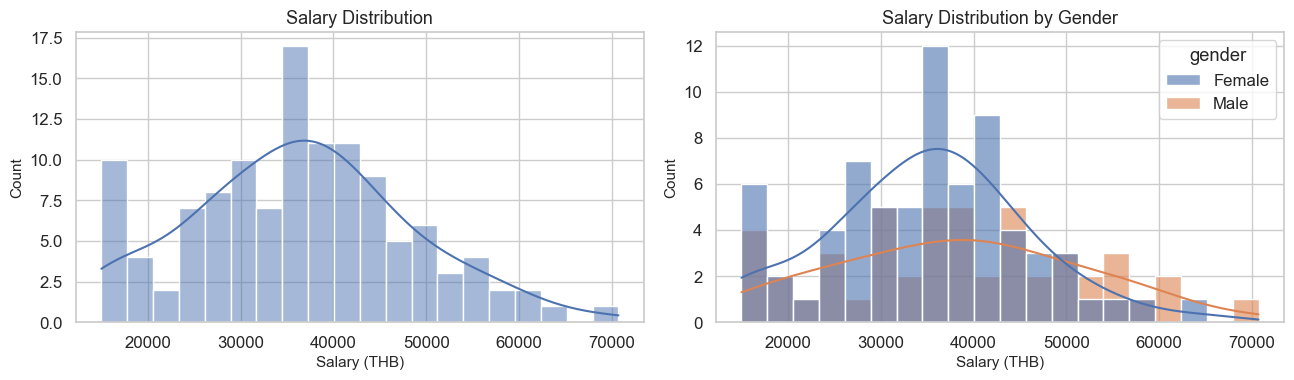

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=df_clean, x='salary', bins=20, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title("Salary Distribution")
axes[0].set_xlabel("Salary (THB)")

sns.histplot(data=df_clean, x='salary', hue='gender', bins=20, kde=True,
             ax=axes[1], element='bars', alpha=0.6, palette=['#4C72B0','#DD8452'])
axes[1].set_title("Salary Distribution by Gender")
axes[1].set_xlabel("Salary (THB)")

plt.tight_layout()
plt.show()


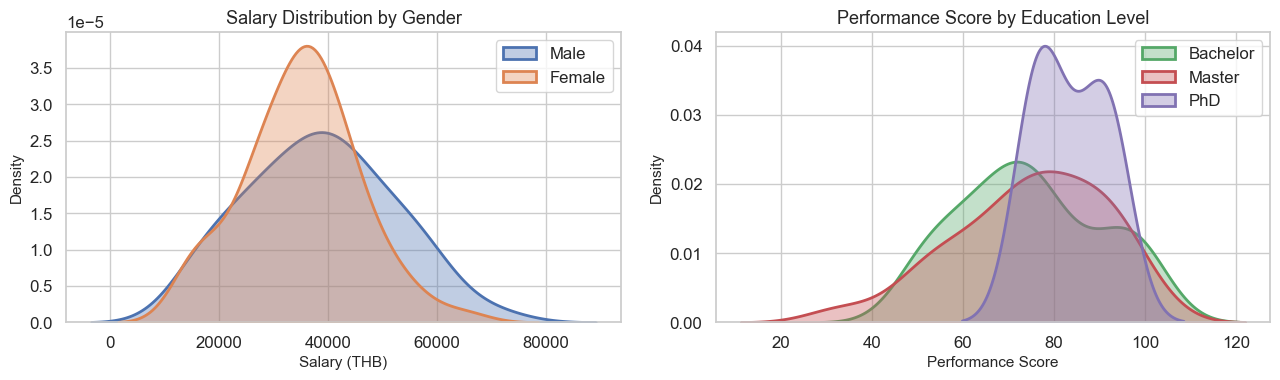

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Salary by Gender - KDE
for gender, color in zip(['Male', 'Female'], ['#4C72B0', '#DD8452']):
    subset = df_clean[df_clean['gender'] == gender]['salary']
    sns.kdeplot(
        subset,
        ax=axes[0],
        label=gender,
        color=color,
        fill=True,
        alpha=0.35,
        linewidth=2
    )

axes[0].set_title("Salary Distribution by Gender")
axes[0].set_xlabel("Salary (THB)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Performance Score by Education Level - KDE
for edu, color in zip(['Bachelor', 'Master', 'PhD'], ['#55A868', '#C44E52', '#8172B2']):
    subset = df_clean[df_clean['education'] == edu]['performance_score']
    sns.kdeplot(
        subset,
        ax=axes[1],
        label=edu,
        color=color,
        fill=True,
        alpha=0.35,
        linewidth=2
    )

axes[1].set_title("Performance Score by Education Level")
axes[1].set_xlabel("Performance Score")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

### 8.3 Boxplot


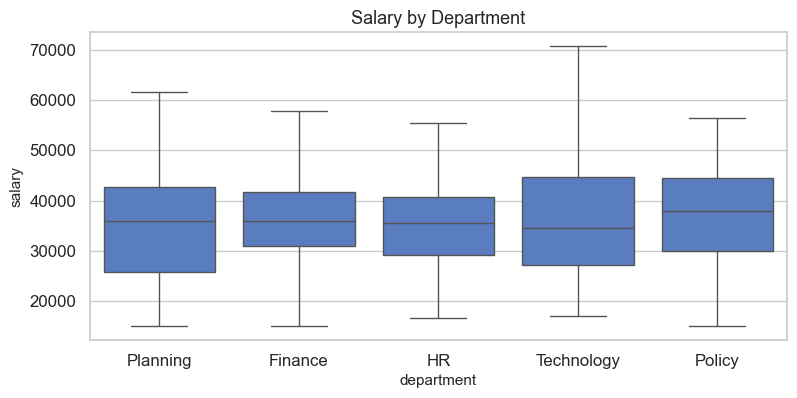

In [ ]:
# Simple
sns.boxplot(data=df_clean, x='department', y='salary')
plt.title("Salary by Department")
plt.show()

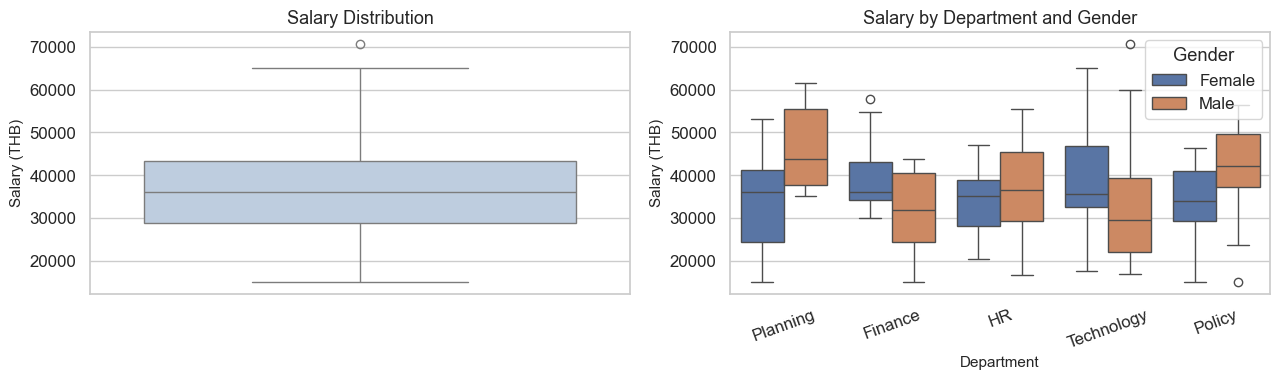

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=df_clean, y='salary', ax=axes[0], color='#B8CCE4')
axes[0].set_title("Salary Distribution")
axes[0].set_ylabel("Salary (THB)")

sns.boxplot(data=df_clean, x='department', y='salary', hue='gender',
            ax=axes[1], palette=['#4C72B0','#DD8452'])
axes[1].set_title("Salary by Department and Gender")
axes[1].set_xlabel("Department")
axes[1].set_ylabel("Salary (THB)")
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Gender')

plt.tight_layout()
plt.show()


### 8.4 Scatterplot


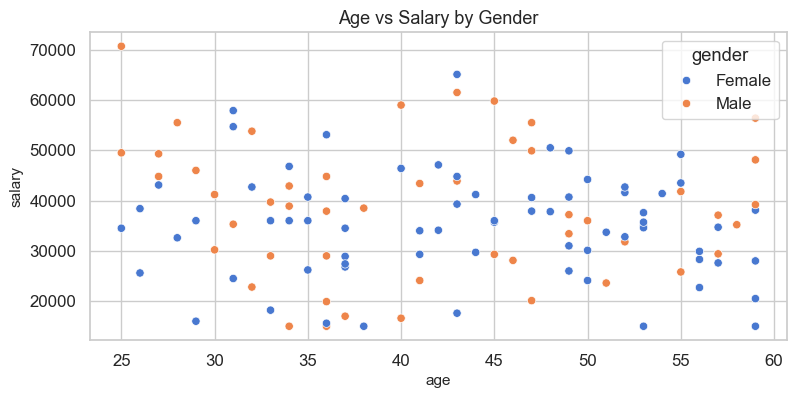

In [ ]:
# Simple
sns.scatterplot(data=df_clean, x='age', y='salary', hue='gender')
plt.title("Age vs Salary by Gender")
plt.show()

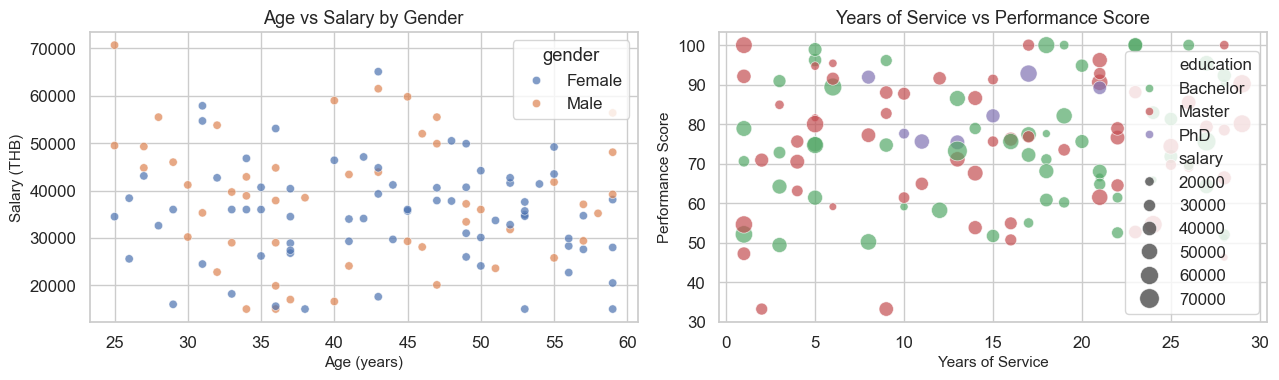

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.scatterplot(data=df_clean, x='age', y='salary', hue='gender',
                ax=axes[0], palette=['#4C72B0','#DD8452'], alpha=0.7)
axes[0].set_title("Age vs Salary by Gender")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Salary (THB)")

sns.scatterplot(data=df_clean, x='years_of_service', y='performance_score',
                hue='education', size='salary',
                ax=axes[1], alpha=0.7,
                palette=['#55A868','#C44E52','#8172B2'], sizes=(30, 200))
axes[1].set_title("Years of Service vs Performance Score")
axes[1].set_xlabel("Years of Service")
axes[1].set_ylabel("Performance Score")

plt.tight_layout()
plt.show()


### 8.5 Pairplot

ดูความสัมพันธ์ของทุกคู่ของตัวแปรตัวเลขในครั้งเดียว  
แนวทแยง = distribution ของแต่ละตัวแปร | นอกแนวทแยง = scatterplot


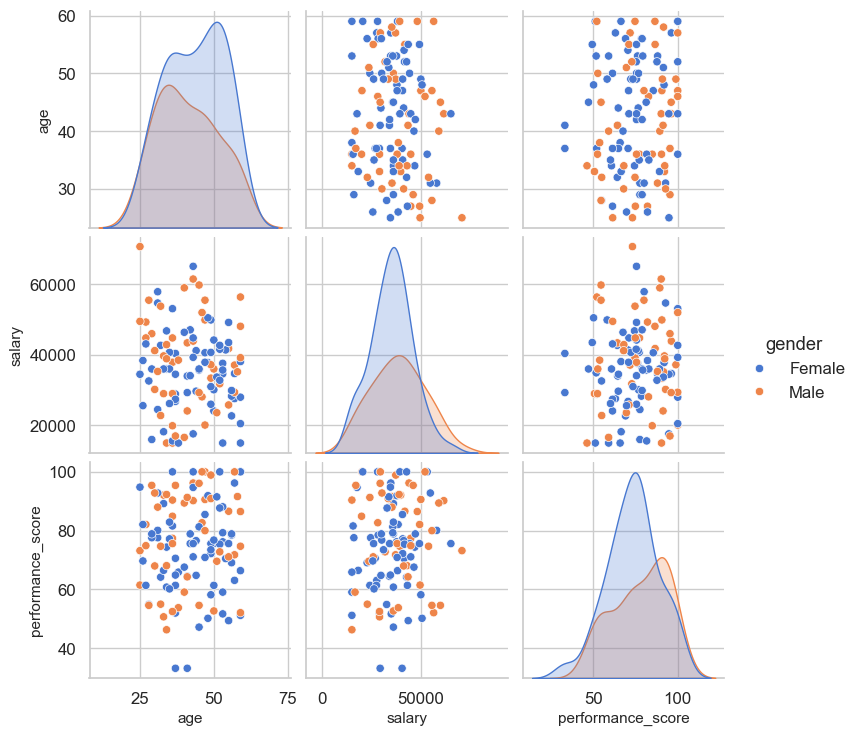

In [ ]:
# Simple
sns.pairplot(df_clean[['age', 'salary', 'performance_score', 'gender']], hue='gender')
plt.show()

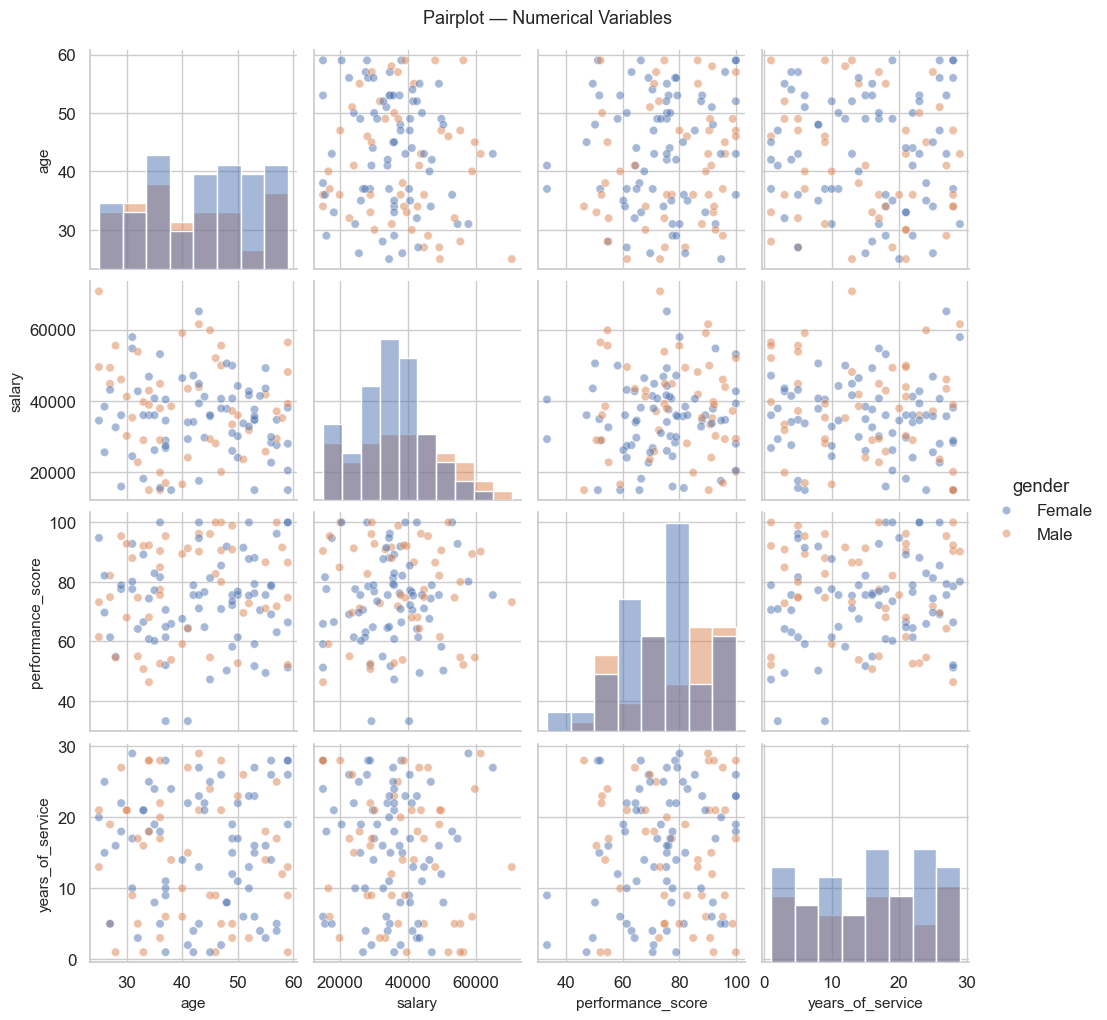

In [38]:
g = sns.pairplot(
    df_clean[['age','salary','performance_score','years_of_service','gender']],
    hue='gender', diag_kind='hist',
    plot_kws={'alpha': 0.5},
    palette=['#4C72B0','#DD8452']
)
g.fig.suptitle("Pairplot — Numerical Variables", y=1.02, fontsize=13)
plt.show()


### 8.6 Heatmap — Correlation Matrix

**ตรวจสอบความสัมพันธ์ระหว่าง column**
- ค่าใกล้ +1 = สัมพันธ์บวก (ตัวหนึ่งมาก อีกตัวมากตาม)
- ค่าใกล้ -1 = สัมพันธ์ลบ (ตัวหนึ่งมาก อีกตัวน้อยลง)  
- ค่าใกล้  0 = แทบไม่มีความสัมพันธ์


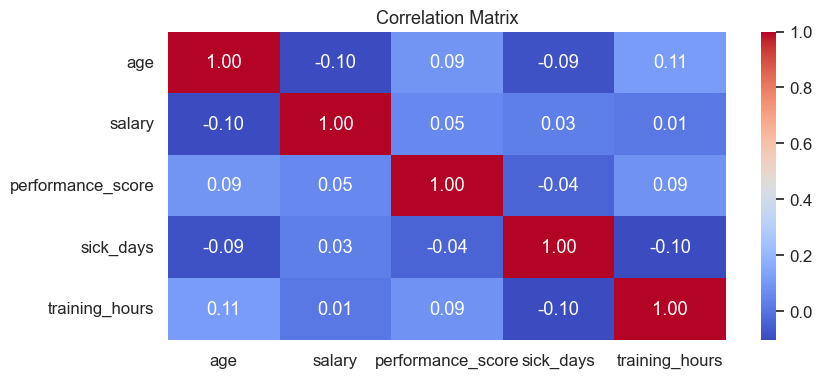

In [ ]:
# Simple
num_cols = ['age', 'salary', 'performance_score', 'sick_days', 'training_hours']
sns.heatmap(df_clean[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

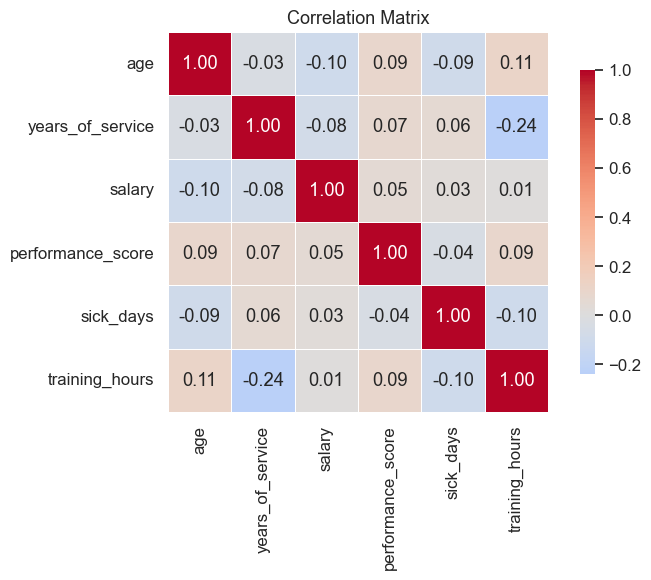

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))

num_cols = ['age','years_of_service','salary','performance_score','sick_days','training_hours']
corr = df_clean[num_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()


### Playground

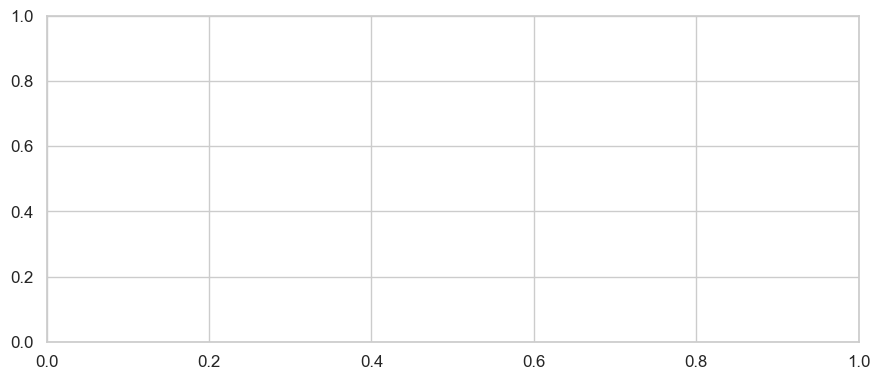

In [40]:
# ลองทำข้อใดข้อหนึ่ง หรือทำกราฟที่ตนเองสนใจเล่นดูได้:
#
# ก) countplot แสดงจำนวนบุคลากรแยกตาม position
#    sns.countplot(data=df_clean, x=???, ...)
#
# ข) boxplot แสดง performance_score แยกตาม education
#    sns.boxplot(data=df_clean, x=???, y=???, ...)
#
# ค) scatterplot ระหว่าง training_hours กับ performance_score
#    sns.scatterplot(data=df_clean, x=???, y=???, hue='department', ...)

fig, ax = plt.subplots(figsize=(9, 4))
# เขียนโค้ดที่นี่:

plt.tight_layout()
plt.show()


---
## 9. PCA — ลดมิติข้อมูล <a id="s9"></a>

**PCA (Principal Component Analysis)** แปลงตัวแปรหลาย ๆ ตัวให้เป็นตัวแปรใหม่จำนวนน้อยลง  
โดยยังรักษาข้อมูลสำคัญไว้ให้มากที่สุด เพื่อให้ visualize บนกราฟ 2D ได้

**ขั้นตอน:**
1. เลือกตัวแปรตัวเลข
2. Standardize ข้อมูล (ทำให้ scale เท่ากัน)
3. Apply PCA
4. Plot ผล


In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = ['age', 'years_of_service', 'salary', 'performance_score', 'sick_days', 'training_hours']
X = df_clean[features].dropna()
idx = X.index

print(f"Features: {len(features)} columns, {len(X)} rows")


Features: 6 columns, 120 rows


In [42]:
# Standardize — ทำ scale ให้เท่ากัน
# จำเป็นเพราะ salary (หน่วยหมื่น) กับ sick_days (หน่วยวัน) scale ต่างกันมาก
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [43]:
# Apply PCA — ลดเหลือ 2 มิติ
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

variance_ratio = pca.explained_variance_ratio_
print(f"PC1: {variance_ratio[0]*100:.1f}%")
print(f"PC2: {variance_ratio[1]*100:.1f}%")
print(f"Total: {sum(variance_ratio)*100:.1f}%")

loadings = pd.DataFrame(pca.components_.T, columns=['PC1','PC2'], index=features)
loadings.round(3)


PC1: 22.6%
PC2: 19.0%
Total: 41.6%


,PC1,PC2
age,0.392,-0.510
years_of_service,-0.503,-0.495
salary,0.018,0.577
performance_score,0.196,-0.317
sick_days,-0.397,0.208
training_hours,0.630,0.136


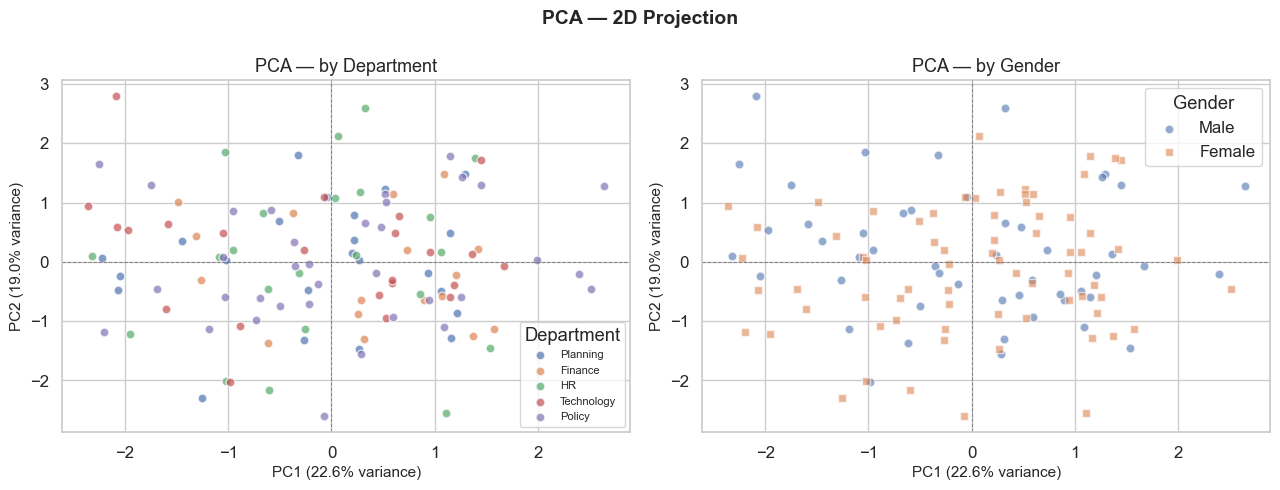

In [44]:
# Plot PCA Result
df_pca = df_clean.loc[idx].copy()
df_pca['PC1'] = X_pca[:, 0]
df_pca['PC2'] = X_pca[:, 1]

dept_colors = {d: c for d, c in zip(df_pca['department'].unique(),
               ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'])}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for dept, color in dept_colors.items():
    sub = df_pca[df_pca['department'] == dept]
    axes[0].scatter(sub['PC1'], sub['PC2'], label=dept, color=color,
                    alpha=0.7, s=40, edgecolors='white')
axes[0].set_title(f"PCA — by Department")
axes[0].set_xlabel(f"PC1 ({variance_ratio[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({variance_ratio[1]*100:.1f}% variance)")
axes[0].legend(fontsize=8, title='Department')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.7)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=0.7)

for gender, color, marker in zip(['Male','Female'], ['#4C72B0','#DD8452'], ['o','s']):
    sub = df_pca[df_pca['gender'] == gender]
    axes[1].scatter(sub['PC1'], sub['PC2'], label=gender, color=color,
                    marker=marker, alpha=0.6, s=40, edgecolors='white')
axes[1].set_title("PCA — by Gender")
axes[1].set_xlabel(f"PC1 ({variance_ratio[0]*100:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({variance_ratio[1]*100:.1f}% variance)")
axes[1].legend(title='Gender')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.7)
axes[1].axvline(0, color='gray', linestyle='--', linewidth=0.7)

plt.suptitle("PCA — 2D Projection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 10. K-Means Clustering <a id="s10"></a>

**K-Means** แบ่งข้อมูลออกเป็น k กลุ่ม โดยข้อมูลในกลุ่มเดียวกันจะ "คล้ายกัน" มากที่สุด

**ตัวอย่างการใช้งาน:** จัดกลุ่มบุคลากรตามรูปแบบการทำงาน เพื่อออกแบบนโยบายได้ตรงจุดขึ้น

**ขั้นตอน:**
1. กำหนด k (จำนวนกลุ่ม)
2. สุ่มจุดศูนย์กลาง k จุด
3. แต่ละจุดข้อมูลไปอยู่กับจุดศูนย์กลางที่ใกล้ที่สุด
4. คำนวณจุดศูนย์กลางใหม่
5. ทำซ้ำจนไม่มีการเปลี่ยนแปลง


In [45]:
from sklearn.cluster import KMeans
X_kmeans = X_pca

inertia = []
k_range = range(1, 9)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_kmeans)
    inertia.append(model.inertia_)

inertia_table = pd.DataFrame({
    'k': list(k_range),
    'inertia': inertia
})

inertia_table

,k,inertia
0,1,299.470732
1,2,183.718364
2,3,124.967532
3,4,90.294463
4,5,76.430490
5,6,65.267693
6,7,56.641630
7,8,49.746024


In [46]:
inertia_table['drop_from_previous'] = inertia_table['inertia'].diff().abs()
inertia_table

,k,inertia,drop_from_previous
0,1,299.470732,NaN
1,2,183.718364,115.752368
2,3,124.967532,58.750832
3,4,90.294463,34.673069
4,5,76.430490,13.863974
5,6,65.267693,11.162797
6,7,56.641630,8.626062
7,8,49.746024,6.895607


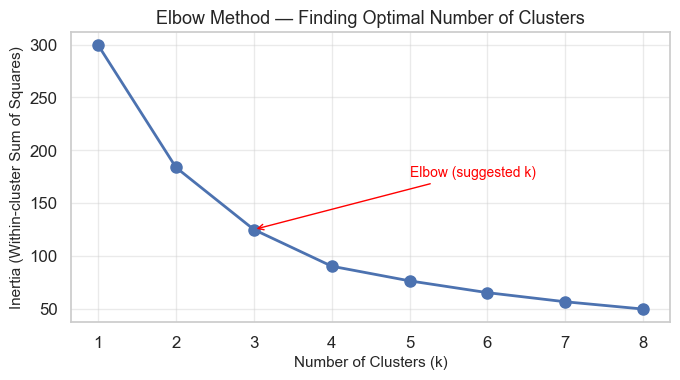

In [47]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_range, inertia, marker='o', color='#4C72B0', linewidth=2, markersize=8)
ax.set_title("Elbow Method — Finding Optimal Number of Clusters")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia (Within-cluster Sum of Squares)")
ax.set_xticks(k_range)
ax.grid(True, alpha=0.4)
ax.annotate('Elbow (suggested k)',
            xy=(3, inertia[2]),
            xytext=(5, inertia[2] + (inertia[0]-inertia[-1])*0.2),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')
plt.tight_layout()
plt.show()


In [48]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_pca['cluster'] = kmeans.fit_predict(X_kmeans)

df_pca['cluster'].value_counts().sort_index()


cluster
0    46
1    41
2    33
Name: count, dtype: int64

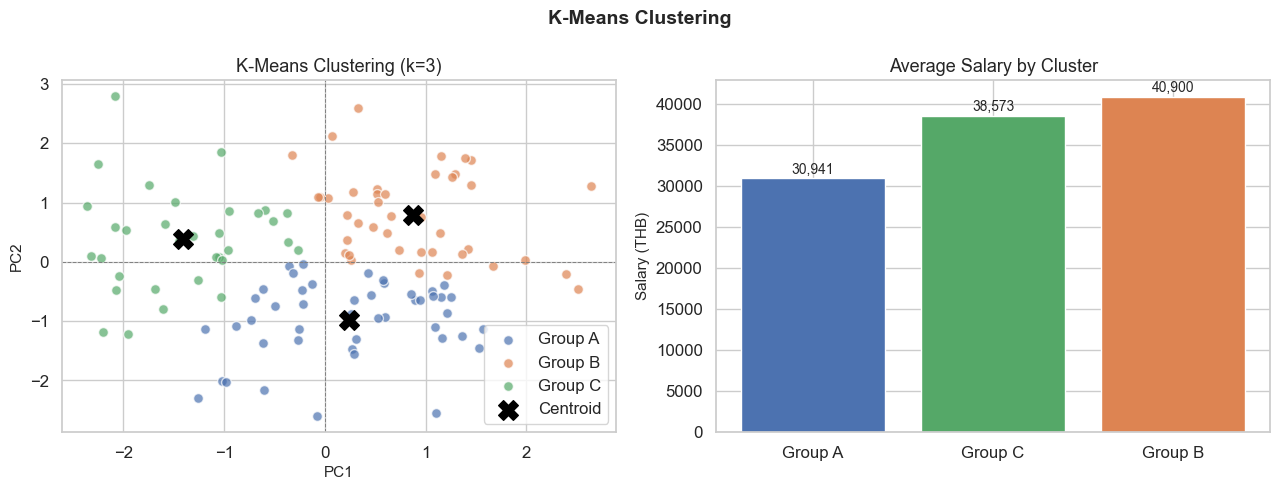

In [49]:
cluster_colors = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868'}
cluster_names  = {0: 'Group A',  1: 'Group B',  2: 'Group C'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for c in [0, 1, 2]:
    sub = df_pca[df_pca['cluster'] == c]
    axes[0].scatter(sub['PC1'], sub['PC2'],
                    label=cluster_names[c], color=cluster_colors[c],
                    alpha=0.7, s=50, edgecolors='white')
centroids = kmeans.cluster_centers_
axes[0].scatter(centroids[:,0], centroids[:,1],
                c='black', s=200, marker='X', zorder=5, label='Centroid')
axes[0].set_title("K-Means Clustering (k=3)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.7)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=0.7)

cluster_profile = df_pca.groupby('cluster')['salary'].mean().sort_values()
bars = axes[1].bar(
    [cluster_names[i] for i in cluster_profile.index],
    cluster_profile.values,
    color=[cluster_colors[i] for i in cluster_profile.index],
    edgecolor='white'
)
for bar, val in zip(bars, cluster_profile.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=10)
axes[1].set_title("Average Salary by Cluster")
axes[1].set_ylabel("Salary (THB)")

plt.suptitle("K-Means Clustering", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [50]:
# Cluster Profile
profile_cols = ['salary','age','years_of_service','performance_score','training_hours','sick_days']
cluster_summary = df_pca.groupby('cluster')[profile_cols].mean().round(1)
cluster_summary.index = [cluster_names[i] for i in cluster_summary.index]
cluster_summary.T


,Group A,Group B,Group C
salary,30941.3,40900.0,38572.7
age,48.7,42.1,34.8
years_of_service,18.8,7.9,19.4
performance_score,80.9,72.4,70.6
training_hours,61.6,86.6,31.2
sick_days,7.6,9.0,13.4


---
## แนวทางเพิ่มเติมเรื่องการเลือกใช้กราฟ

| ต้องการดูอะไร | กราฟที่เหมาะ |
|--------------|-------------|
| เปรียบเทียบจำนวน/ค่าเฉลี่ยระหว่างกลุ่ม | Bar Chart |
| สัดส่วนจากทั้งหมด | Pie Chart |
| การกระจายตัวของข้อมูล | Histogram |
| การกระจาย + Outlier | Boxplot |
| ความสัมพันธ์ระหว่าง 2 ตัวแปร | Scatterplot |
| ความสัมพันธ์ทุก pair พร้อมกัน | Pairplot |
| Correlation overview | Heatmap |
